<a href="https://colab.research.google.com/github/Loopinlogix/Midterm_Diabetes/blob/main/Midterm_Project_Diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 10: Midterm Project

## Review of Machine Learning Concepts:

**Machine Learning (ML):** This is a part of Artificial Intelligence where computers learn from data without being explicitly programmed. Instead of following strict rules, they find patterns on their own.

**Supervised Learning:** This type of learning uses data that already has answers (labels). The computer is given input information (`X`) and the correct results (`y`). Since the 'target' variable in our Diabetes dataset (disease progression) is a number that can change smoothly (like a temperature or a score), this particular task is called **regression**.

**Key Components:**

*   **Features (`X`):** These are the pieces of information we use to make predictions. In our case, these are ten initial measurements like age, gender, body mass index, blood pressure, and six blood serum measurements.
*   **Label (`y`):** This is the outcome we are trying to predict. For the Diabetes dataset, it's a number that shows how much the disease progressed one year after the initial measurements.
*   **Model Training:** This is when the computer algorithm learns from the data. It adjusts itself to make predictions that are as close as possible to the actual answers, trying to minimize any errors.
*   **Model Evaluation:** After training, we test the model on new, unseen data to see how well it predicts. This helps us understand if the model will work well in real-world situations.

In [13]:
#Github Repository
#Github

#Github
!apt-get install -y git
!git config --global user.email "crystal_macneil@hotmail.com"
!git config --global user.name "Crystal MacNeil"

!git clone https://github.com/Loopinlogix/Midterm_Diabetes.git
%cd Midterm_Diabetes.git
!ls

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.17).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
fatal: destination path 'Midterm_Diabetes' already exists and is not an empty directory.
[Errno 2] No such file or directory: 'Midterm_Diabetes.git'
/content
Midterm_Diabetes  sample_data


In [14]:
# Remove existing directory
!rm -rf Midterm_Diabetes

# Re-clone the repository
!git clone https://github.com/Loopinlogix/Midterm_Diabetes.git
%cd Midterm_Diabetes
!ls

Cloning into 'Midterm_Diabetes'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.
/content/Midterm_Diabetes
README.md


# Step # 1 -Loading and ED
Using Sklearn and inspect the dataset

Dataset Shape: (442, 11)

First 5 rows:
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null 

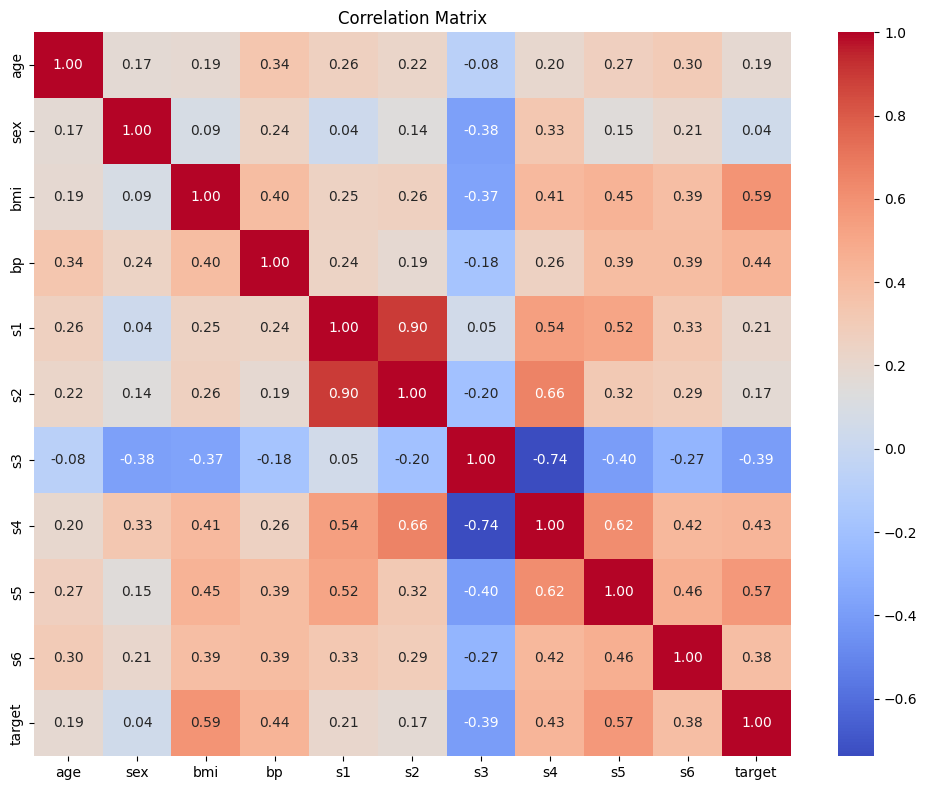

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes

# 1. Load dataset
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nSummary Statistics:")
print(df.describe())

# 2. Visualize correlations with the target variable ('target')
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

##Step 2 - Split Data into Train/Test sets and apply standard scalers.  
The Diabetes dataset from SKlearn already come precentered and scaled by standard deviation.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Check for missing values
print("Missing values count:")
print(df.isnull().sum())

# 2. Separate features (X) and target (y)
X = df.drop(columns=['target'])
y = df['target']

# 3. Train-Test Split (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('X_train head:')
display(pd.DataFrame(X_train_scaled, columns=X.columns).head())

print('\nX_test head:')
display(pd.DataFrame(X_test_scaled, columns=X.columns).head())

print('\ny_train head:')
display(y_train.head())

print('\ny_test head:')
display(y_test.head())

# 4. Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Missing values count:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64
X_train head:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,1.498365,1.061370,0.219902,1.138874,0.728473,1.055893,-0.824451,0.711038,0.547482,-0.061449
1,-0.228858,1.061370,-0.419366,-0.710591,-0.424929,0.272425,-1.529791,1.484286,-0.019757,0.367236
2,0.085182,-0.942179,1.018987,1.992473,-0.309589,-0.326699,-0.119111,-0.062210,0.331237,-0.318660
3,-0.621409,-0.942179,-0.784662,-0.639458,-1.174640,-1.215508,0.664600,-0.835458,-1.069682,-2.719299
4,-0.542899,-0.942179,-1.423930,-1.706457,-0.799784,-1.110167,1.291569,-1.608706,-0.802859,-0.918820



X_test head:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.948794,-0.942179,-0.168225,-0.354925,2.631586,2.649166,0.429487,0.711038,0.653601,-0.147186
1,1.969426,-0.942179,0.745015,0.427541,-0.511434,-0.333282,0.037631,-0.835458,-0.496909,-0.490134
2,1.341345,1.061370,-0.122563,-0.283791,2.170225,1.042726,1.213198,-0.062210,1.743607,-0.404397
3,2.047936,-0.942179,1.064649,1.613333,1.160999,0.785959,-1.608162,2.953457,2.040014,1.224607
4,0.242203,1.061370,-0.465028,-0.070392,0.814978,1.134899,-0.119111,0.711038,-0.133128,-0.232923



y_train head:


,target
17,144.0
66,150.0
137,280.0
245,125.0
31,59.0



y_test head:


,target
287,219.0
211,70.0
72,202.0
321,230.0
73,111.0


#Step 3 - Train Baseline and regression models
Compare models

In [9]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Initialize models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

# Fit models on scaled training data
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    print(f"{name} trained successfully.")

Linear Regression trained successfully.
Ridge Regression trained successfully.
Lasso Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.


#Step 4 - Evaluate the Model performance
Calculate metrics and analyze any risidual distributions

            Model         MSE      RMSE       MAE       R2
Linear Regression 2900.193628 53.853446 42.794095 0.452603
 Ridge Regression 2892.014566 53.777454 42.811999 0.454147
 Lasso Regression 2884.624289 53.708698 42.805234 0.455541
    Decision Tree 4887.000000 69.907081 53.921348 0.077603
    Random Forest 2959.180562 54.398351 44.171236 0.441469


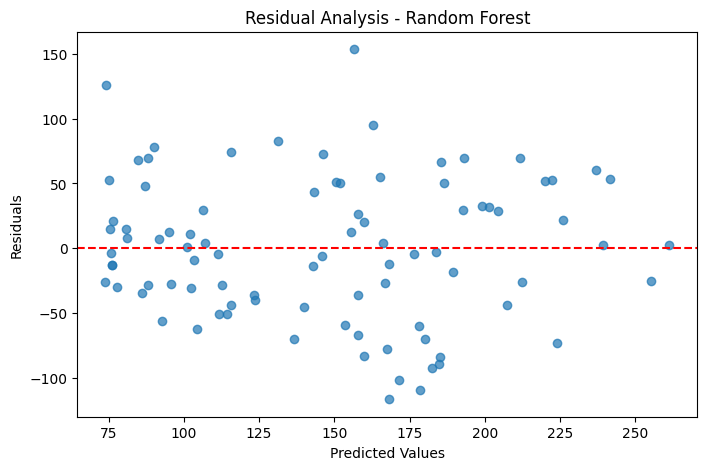

In [4]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_models(models, X_test, y_test):
    results = []
    for name, model in models.items():
        preds = model.predict(X_test)
        mse = mean_squared_error(y_test, preds)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, preds)
        r2 = r2_score(y_test, preds)
        results.append({"Model": name, "MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2})
    return pd.DataFrame(results)

results_df = evaluate_models(models, X_test_scaled, y_test)
print(results_df.to_string(index=False))

# Residual Plot for Random Forest
best_model = models["Random Forest"]
preds = best_model.predict(X_test_scaled)
residuals = y_test - preds

plt.figure(figsize=(8, 5))
plt.scatter(preds, residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Analysis - Random Forest")
plt.show()

### Model Performance Comparison
Visualization of Model Comparison

#Visualization of Model Comparison

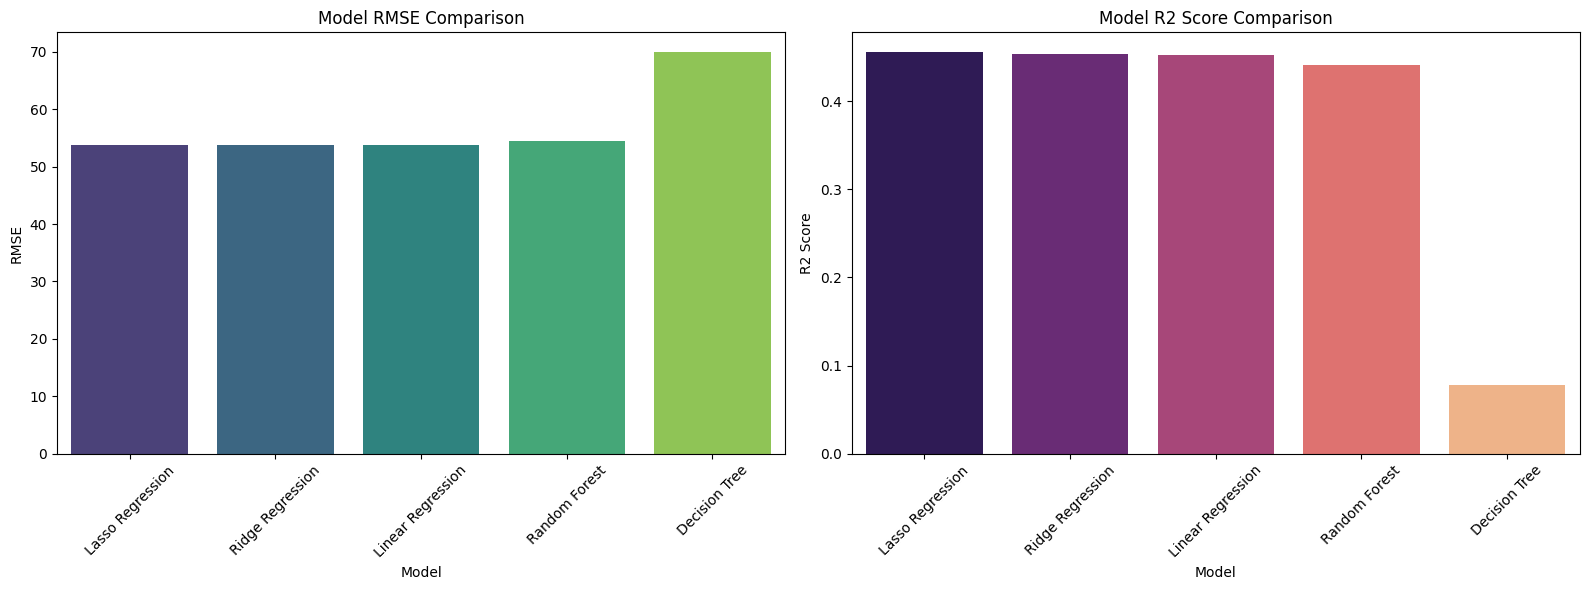

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x='Model', y='RMSE', hue='Model', data=results_df.sort_values(by='RMSE', ascending=True),
            palette='viridis', ax=axes[0], legend=False)
axes[0].set_title('Model RMSE Comparison')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(x='Model', y='R2', hue='Model', data=results_df.sort_values(by='R2', ascending=False),
            palette='magma', ax=axes[1], legend=False)
axes[1].set_title('Model R2 Score Comparison')
axes[1].set_ylabel('R2 Score')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#Step 5 - Hyperparameter Tuning and & Optimization
Optimiza model performance using GridSearchCV - 5 fold cross validation to tune the top performing model.

In [5]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid for Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search.best_params_)
best_rf = grid_search.best_estimator_

# Evaluate tuned model
best_preds = best_rf.predict(X_test_scaled)
print("Tuned Test RMSE:", np.sqrt(mean_squared_error(y_test, best_preds)))
print("Tuned Test R2 Score:", r2_score(y_test, best_preds))

Best Parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}
Tuned Test RMSE: 53.49780591256025
Tuned Test R2 Score: 0.45980874589723


# Step 6 - Feature Importance and Ethics
Extract feature impoertance and address ethical consideration.

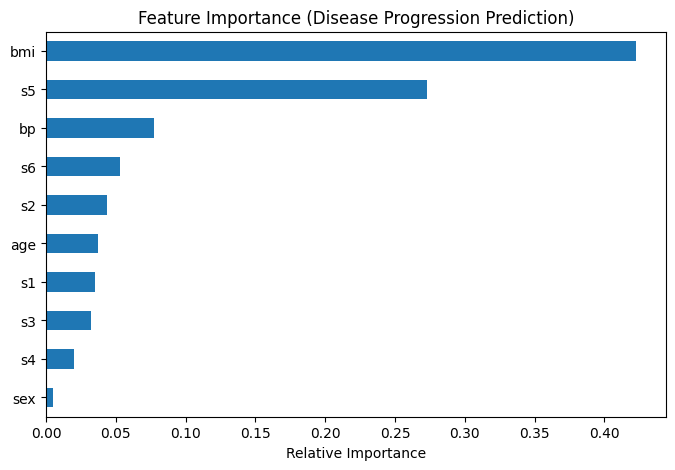

In [6]:
# Extract feature importance from Random Forest
importances = pd.Series(best_rf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(8, 5))
plt.title("Feature Importance (Disease Progression Prediction)")
plt.xlabel("Relative Importance")
plt.show()